# **MÓDULO 17 - Projeto de Credit Score - Parte 1 - Processamento dos dados**


Essa é a primeira etapa do processo de Credit Score que vocês desenvolverão durante nosso curso.
Nessa primeira etapa vocês irão aplicar os passos aprendidos nos módulos de pré processamento para preparar a base de vocês para o desenvolvimento do modelo.

O termo "credit score" se refere a uma pontuação numérica que representa a credibilidade de um indivíduo em termos de cumprimento de obrigações financeiras, como pagar contas de empréstimos, cartões de crédito, entre outros. Essa pontuação é calculada com base em diversas informações financeiras e de crédito do indivíduo, como histórico de pagamentos, níveis de endividamento, tempo de crédito, tipos de crédito utilizados, entre outros.

O objetivo de um modelo de credit score é prever o risco de um indivíduo se tornar inadimplente com suas obrigações financeiras. Em outras palavras, o modelo avalia a probabilidade de um indivíduo não cumprir com os pagamentos de empréstimos ou outros compromissos financeiros. Essa previsão é fundamental para instituições financeiras, como bancos e credores, na tomada de decisão sobre a concessão de crédito. Um modelo de credit score eficaz pode ajudar essas instituições a avaliar o risco de emprestar dinheiro a um determinado indivíduo e, assim, tomar decisões mais informadas sobre a aprovação ou negação de crédito, bem como sobre os termos e condições desses empréstimos.

**Atenção:** Notem que esse projeto é diferente da base que tenho trabalhado com vocês em aula, apesar de se tratar de uma base bancária durante a aula falamos sobre a variável Churn a ser prevista, nesse caso a previsão seria do valor do Score de Crédito.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

In [ ]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


# Etapa 1: Relize os passos que vimos no módulo 18, de pré processamento dos dados.

**A) Verifique os tipos de dados, fazendo as transformações quando necessário.**


In [ ]:
df = pd.read_csv('/content/CREDIT_SCORE_PROJETO_PARTE1.csv', sep=';')

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    float64
 1   Gender              164 non-null    object 
 2   Income              164 non-null    object 
 3   Education           164 non-null    object 
 4   Marital Status      164 non-null    object 
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    object 
 7   Credit Score        164 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 10.4+ KB


,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High


In [ ]:
df['Income'] = df['Income'].str.replace('.', '', regex=False)
df['Income'] = df['Income'].str.replace(',', '.', regex=False)
df['Income'] = df['Income'].astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    float64
 1   Gender              164 non-null    object 
 2   Income              164 non-null    float64
 3   Education           164 non-null    object 
 4   Marital Status      164 non-null    object 
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    object 
 7   Credit Score        164 non-null    object 
dtypes: float64(2), int64(1), object(5)
memory usage: 10.4+ KB


**B) Verifique se temos colunas com dados faltantes.
Caso existam colunas com dados faltantes faça o tratamento desses dados, excluindo ou substituindo esses valores. Justifique sua escolha.**

In [ ]:
df.isnull().sum()

,0
Age,34
Gender,0
Income,0
Education,0
Marital Status,0
Number of Children,0
Home Ownership,0
Credit Score,0


In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())

## Justificativa

A substituição pela mediana foi escolhida porque:

- Permite manter todos os registros do dataset, evitando a perda de aproximadamente 34 observações caso as linhas fossem removidas.
- Preserva melhor a distribuição original da variável idade, sendo uma técnica comum no pré-processamento de dados para modelos de Machine Learning.

**C) Verifique se temos valores digitados de forma incorreta nas variáveis categóricas que necessitem de tratamento.**

In [ ]:
for col in ['Gender','Education','Marital Status','Home Ownership','Credit Score']:
    print(f'\nValores únicos de {col}:')
    print(df[col].unique())


Valores únicos de Gender:
['Female' 'Male']

Valores únicos de Education:
["Bachelor's Degree" "Master's Degree" 'Doctorate' 'High School Diploma'
 "Associate's Degree"]

Valores únicos de Marital Status:
['Single' 'Married']

Valores únicos de Home Ownership:
['Rented' 'Owned']

Valores únicos de Credit Score:
['High' 'Average' 'Low']


# Etapa 2: Relize os passos que vimos no módulo 15, de análise.

**A) Realiza a análise univariada, aplique a função describe ao nosso dataframe para verificar os dados das variáveis numéricas, se encontrar a possível presença de outliers analise com gráficos a distribuição dos dados.Traga insights sobre os dados analisados.**

In [ ]:
df.describe()

,Age,Income,Number of Children
count,164.000000,164.000000,164.000000
mean,37.195122,83765.243902,0.652439
std,7.586619,32457.306728,0.883346
min,25.000000,25000.000000,0.000000
25%,31.750000,57500.000000,0.000000
50%,36.000000,83750.000000,0.000000
75%,43.000000,105000.000000,1.000000
max,53.000000,162500.000000,3.000000


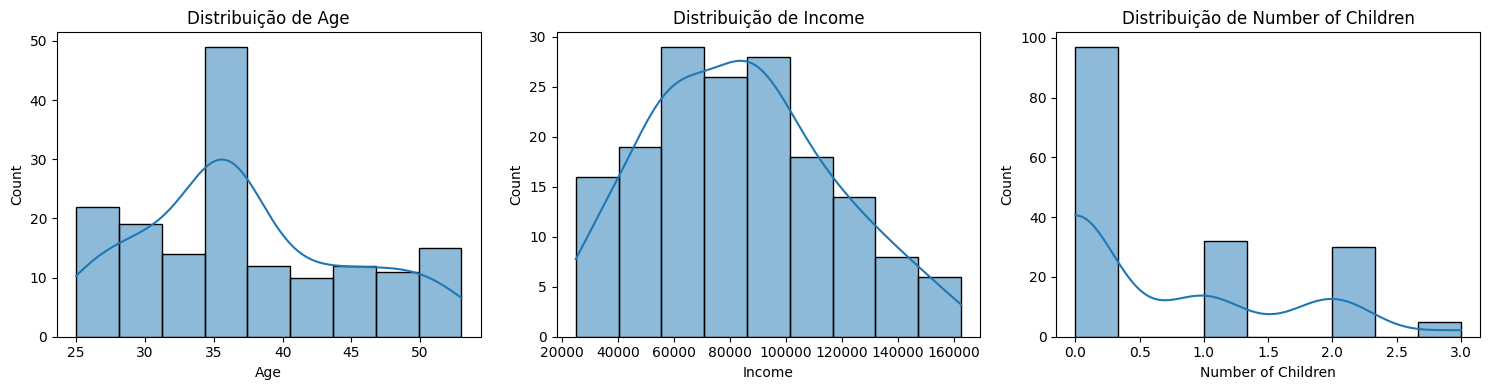

In [ ]:
num_cols = ['Age', 'Income', 'Number of Children']

plt.figure(figsize=(15,4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1,3,i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribuição de {col}')

plt.tight_layout()
plt.show()

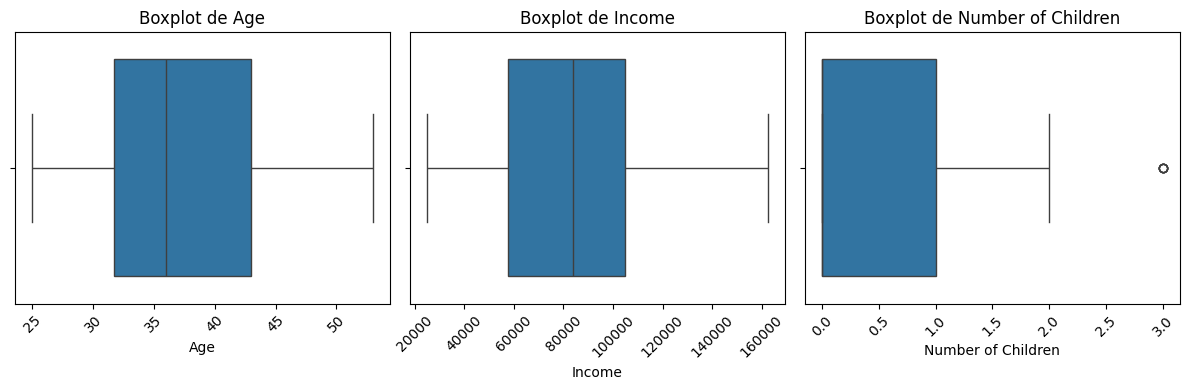

In [ ]:
plt.figure(figsize=(12,4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1,3,i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Insights sobre os dados:

- A maioria dos indivíduos possui idade entre 30 e 45 anos;
- A variável Income apresenta maior dispersão, indicando diferenças - significativas de renda;
- A variável Number of Children é altamente concentrada em valores baixos, principalmente 0 filhos;
- Não foram identificados outliers relevantes nas variáveis Age e Income, enquanto Number of Children apresenta um possível valor extremo.

**B) Agora realize a análise univariada para as variaveis categóricas, plote gráficos para entender a distribuição das categorias e tente retirar insights de cada gráfico.**

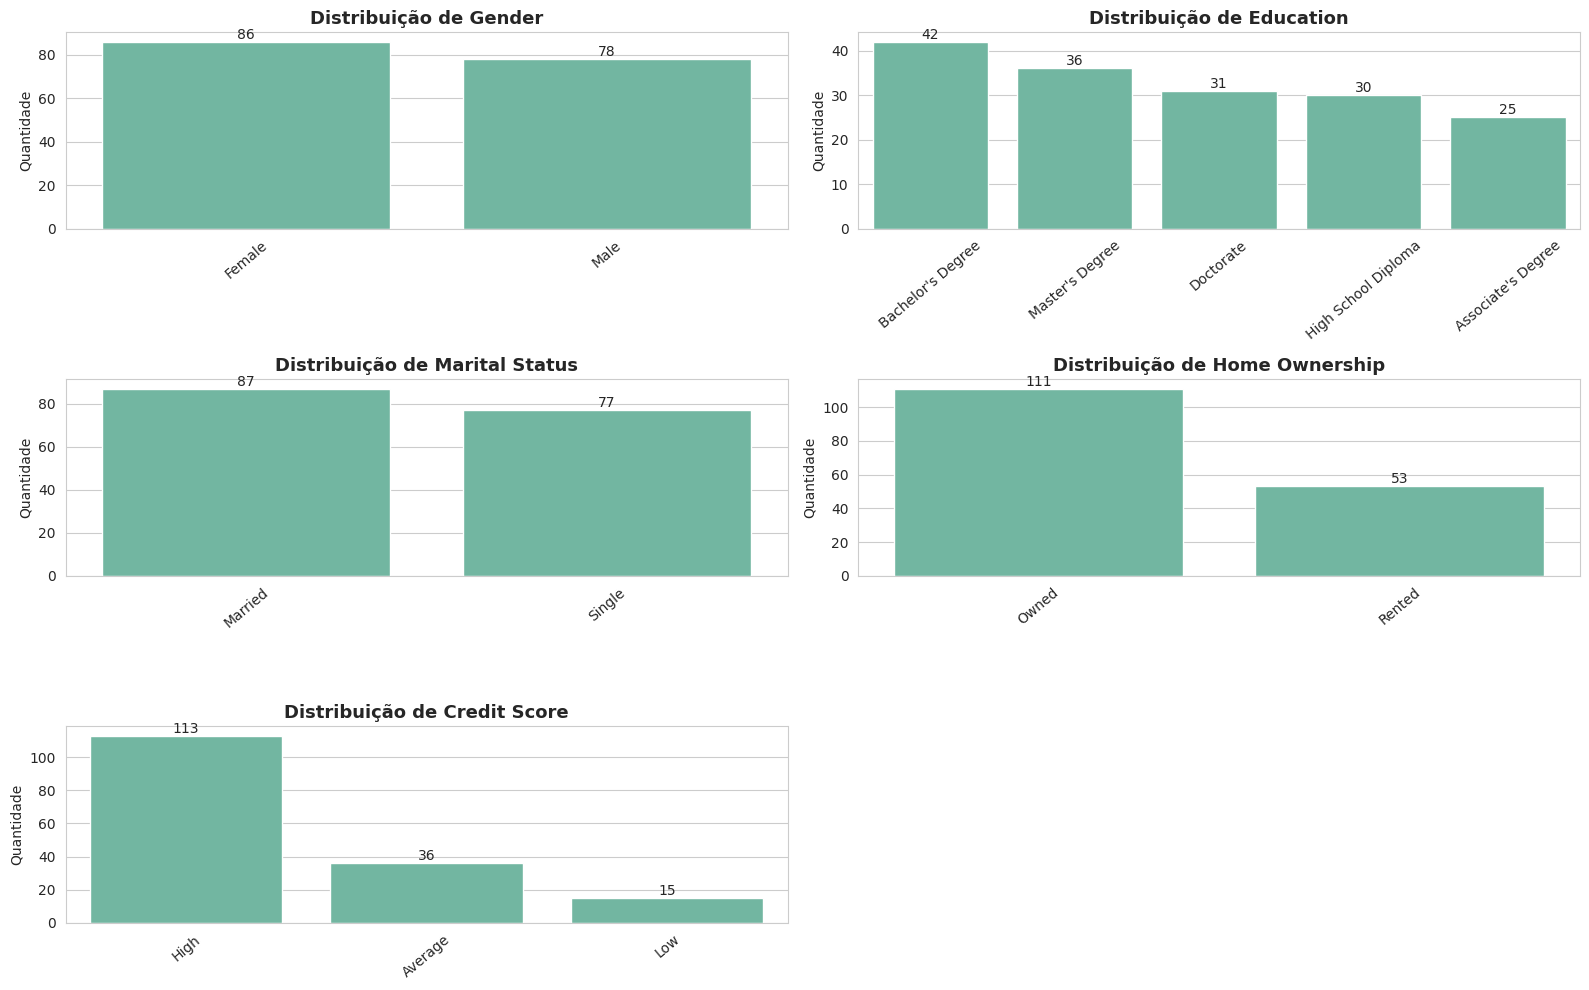

In [ ]:
sns.set_style("whitegrid")
sns.set_palette("Set2")

cat_cols = ['Gender','Education','Marital Status','Home Ownership','Credit Score']

plt.figure(figsize=(16,10))

for i, col in enumerate(cat_cols, 1):
    ax = plt.subplot(3,2,i)

    order = df[col].value_counts().index

    sns.countplot(data=df, x=col, order=order, ax=ax)

    plt.title(f'Distribuição de {col}', fontsize=13, fontweight='bold')
    plt.xticks(rotation=40)
    plt.ylabel("Quantidade")
    plt.xlabel("")

    # mostrar valores nas barras
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom',
                    fontsize=10)

plt.tight_layout()
plt.show()

## Insights dos dados:

- Distribuição relativamente equilibrada entre gêneros;
- Predominância de indivíduos com nível educacional elevado;
- Maioria de pessoas casadas e com imóvel próprio, indicando estabilidade socioeconômica;
- Forte predominância da classe High no Credit Score, o que pode indicar desbalanceamento da variável alvo, fator que deve ser considerado no treinamento.

**C) Você encontrou alguma coluna com outliers?
Se sim realize o tratamento desses casos.**

Number of Children: foi identificado um possível outlier no valor 3, pois a maioria dos dados está concentrada entre 0 e 1 filhos.
- Como o valor 3 filhos representa um valor realista e possível na vida real, optou-se por não remover nem alterar esse dado, pois ele não representa erro de digitação ou inconsistência no dataset.

**D) Realize a análise Bivariada.
Tente responder as seguintes perguntas com gráficos seguidos de insights:**



*   Existe relação entre a idade e o status civil?
*   Qual a relação entre o score de crédito e o nível de escolaridade?
*  O salário parece influenciar na idade?
* O salário parece influenciar no Score de Crédito?
* Clientes com casa própria tendem a ter um score mais alto?



/tmp/ipykernel_359/1208078692.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Marital Status', y='Age', palette="Set2")


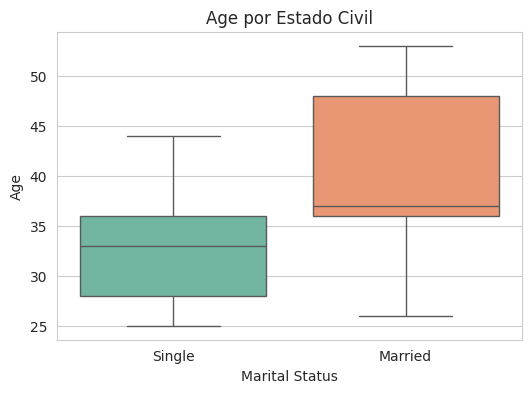

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Marital Status', y='Age', palette="Set2")
plt.title('Age por Estado Civil')
plt.show()

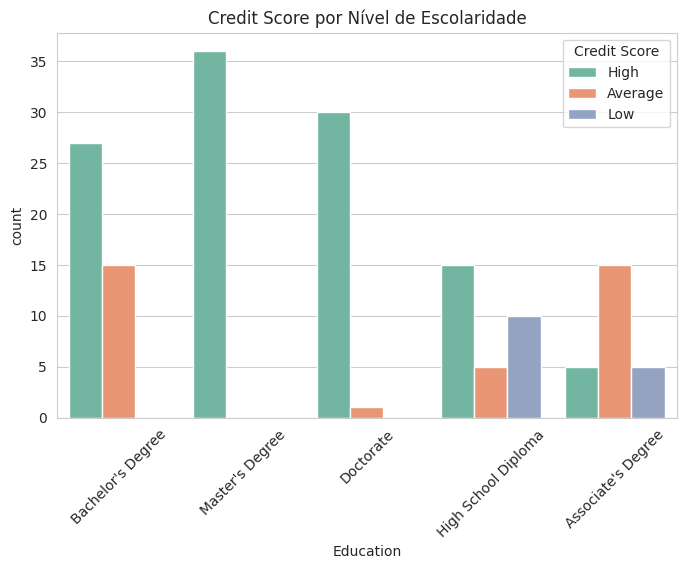

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Education', hue='Credit Score', palette="Set2")
plt.xticks(rotation=45)
plt.title('Credit Score por Nível de Escolaridade')
plt.show()

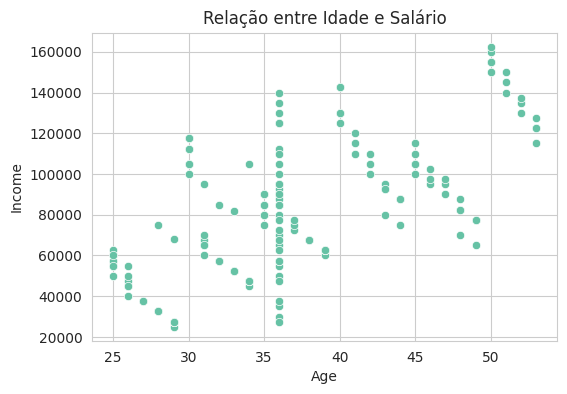

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Age', y='Income')
plt.title('Relação entre Idade e Salário')
plt.show()

/tmp/ipykernel_359/42525957.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Credit Score', y='Income', palette="Set2")


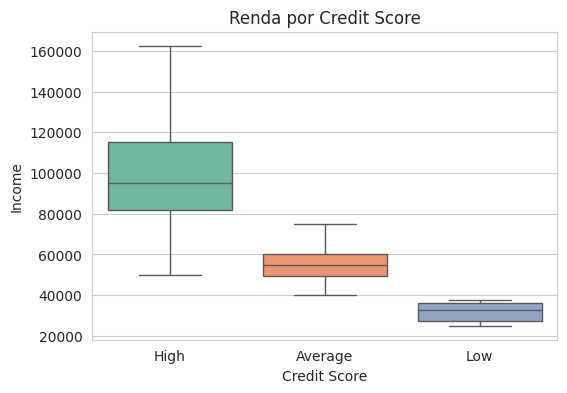

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Credit Score', y='Income', palette="Set2")
plt.title('Renda por Credit Score')
plt.show()

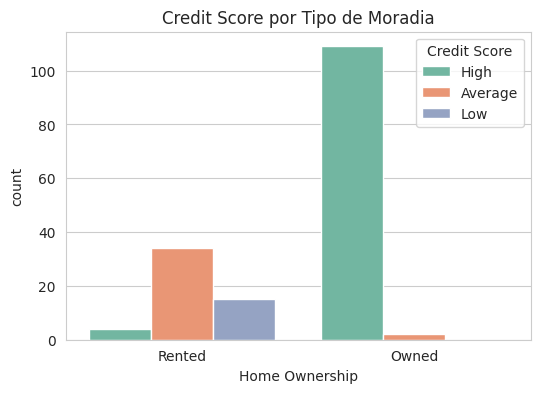

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Home Ownership', hue='Credit Score', palette="Set2")
plt.title('Credit Score por Tipo de Moradia')
plt.show()

## A análise bivariada permite observar relações importantes entre as variáveis do dataset. Os resultados sugerem que:

- Pessoas casadas tendem a ser mais velhas;
- Maior nível educacional pode estar associado a melhores scores de crédito;
- Existe uma possível relação entre idade e renda;
- Renda maior pode estar associada a scores de crédito mais altos;
- Clientes com imóvel próprio tendem a apresentar melhor avaliação de crédito.

**E) Que outras perguntas te parecem fazer sentido explorarmos a resposta para conhecermos mais nossa base de dados e o comportamento dos clientes?**

 Elabore mais 3 perguntas e responda utilizando gráficos + insights.

1) O nível de escolaridade influencia a renda?
2) Pessoas casadas possuem renda maior do que solteiras?
3) O número de filhos influencia o Credit Score?

/tmp/ipykernel_359/1328503322.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Education', y='Income', palette="Set2")


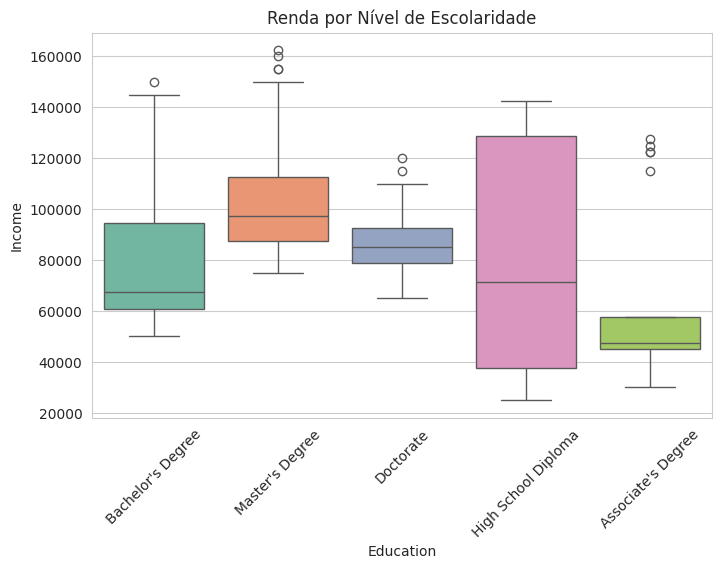

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Education', y='Income', palette="Set2")
plt.xticks(rotation=45)
plt.title('Renda por Nível de Escolaridade')
plt.show()

/tmp/ipykernel_359/1234558792.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Marital Status', y='Income', palette="Set2")


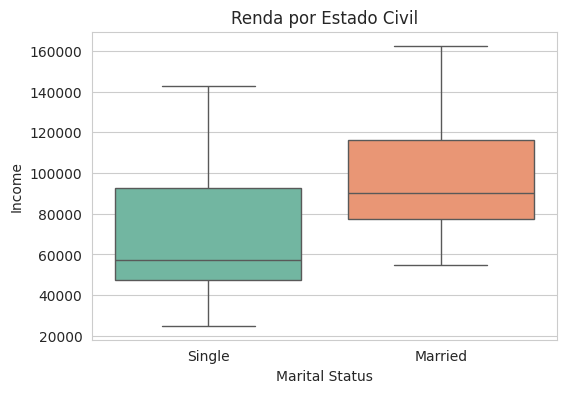

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Marital Status', y='Income', palette="Set2")
plt.title('Renda por Estado Civil')
plt.show()

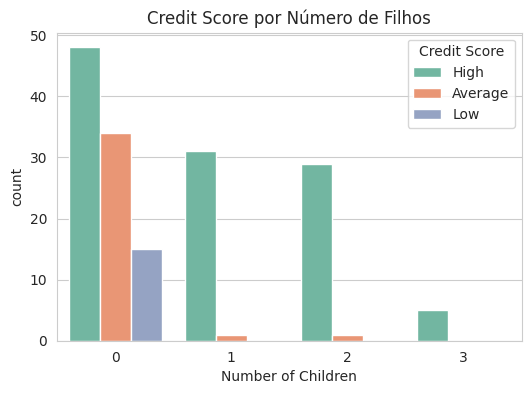

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Number of Children', hue='Credit Score', palette="Set2")
plt.title('Credit Score por Número de Filhos')
plt.show()

- Observa-se que níveis mais altos de escolaridade tendem a apresentar maiores faixas de renda;
- A distribuição de renda mostra que indivíduos casados tendem a apresentar rendas ligeiramente maiores do que os solteiros;
- Não parece ter uma correlação muito forte.

# Etapa 3: Relize os passos que vimos no módulo 17, de Correlação, Balanceamento, atributos categóricos e divisão base treino e teste.

**A) Vamos começar pela análise de correlação, plote da forma que achar melhor a análise de correlação, seja pela tabela ou pelo gráfico da matriz.**

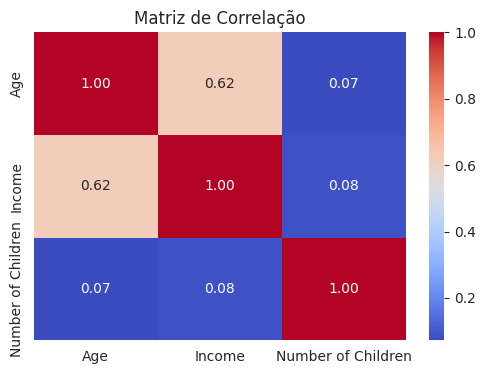

In [ ]:
corr = df[['Age','Income','Number of Children']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

**B) Você encontrou variáveis que tem uma média ou alta correlação? Se sim, quais? Te parece fazer sentido essas variáveis terem alta correlação? Justifique.**

Sim, foi observada uma correlação moderada entre Age e Income (0.62). Isso indica que, em geral, à medida que a idade aumenta, a renda também tende a aumentar. Essa relação faz sentido, pois pessoas mais velhas normalmente possuem mais experiência profissional, maior tempo de carreira e maior estabilidade no mercado de trabalho, o que pode resultar em salários mais altos.

**C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, exclua as colunas categóricas.**

In [ ]:
# identificar colunas categóricas
cat_cols = ['Gender','Education','Marital Status','Home Ownership','Credit Score']

# aplicar One Hot Encoding
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# visualizar resultado
df_encoded.head()

,Age,Income,Number of Children,Gender_Male,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree,Marital Status_Single,Home Ownership_Rented,Credit Score_High,Credit Score_Low
0,25.0,50000.0,0,False,True,False,False,False,True,True,True,False
1,30.0,100000.0,2,True,False,False,False,True,False,False,True,False
2,35.0,75000.0,1,False,False,True,False,False,False,False,True,False
3,40.0,125000.0,0,True,False,False,True,False,True,False,True,False
4,45.0,100000.0,3,False,True,False,False,False,False,False,True,False


**D) Vamos plotar novamente a correlação, agora observando com as variáveis categóricas. Identifique se temos novas variáveis com forte correlação.**

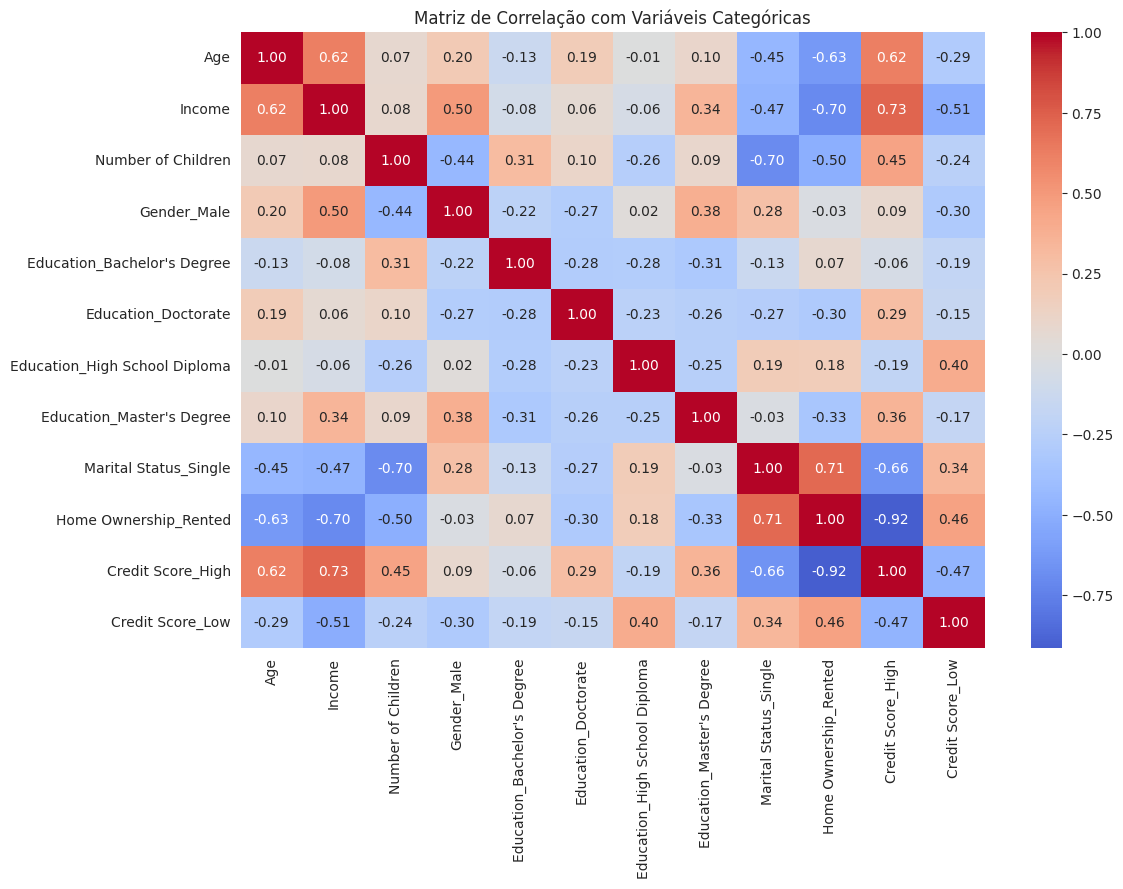

In [ ]:
corr = df_encoded.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)

plt.title('Matriz de Correlação com Variáveis Categóricas')
plt.show()

Sim, após incluir as variáveis categóricas convertidas em numéricas, novas correlações fortes puderam ser observadas.

- Home Ownership_Rented e Credit Score_High (-0.92) apresentam uma correlação negativa muito forte, indicando que clientes que moram de aluguel tendem a ter menor probabilidade de possuir score de crédito alto.
- Marital Status_Single e Home Ownership_Rented (0.71) mostram uma correlação positiva forte, sugerindo que pessoas solteiras têm maior tendência a morar em imóveis alugados.
- Income e Credit Score_High (0.73) apresentam uma correlação positiva forte, indicando que clientes com maior renda tendem a ter score de crédito mais alto.



**F) Faça a separação da base em treino e teste e verifique utilizando shape:**

In [ ]:
from sklearn.model_selection import train_test_split

# variável alvo
y = df_encoded['Credit Score_High']

# variáveis preditoras
X = df_encoded.drop(['Credit Score_High','Credit Score_Low'], axis=1)

# divisão treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# verificar tamanhos
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(131, 10)
(33, 10)
(131,)
(33,)


**G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.**

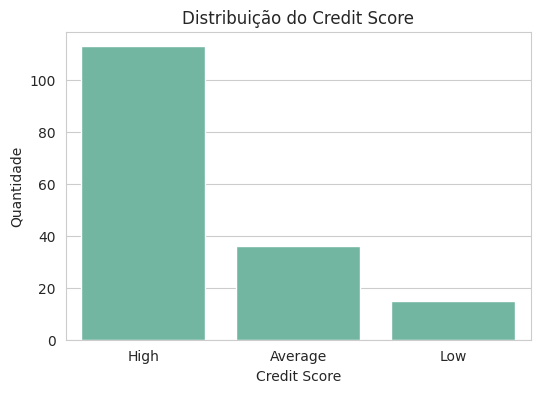

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Credit Score')

plt.title('Distribuição do Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Quantidade')

plt.show()

In [ ]:
# Tabela com contagem de cada Credit Score
tabela = df['Credit Score'].value_counts().reset_index()
tabela.columns = ['Credit Score', 'Quantidade']
tabela = tabela.sort_values('Credit Score')  # ordenar pelo score

print(tabela)

  Credit Score  Quantidade
1      Average          36
0         High         113
2          Low          15


**H) Vamos realizar o balancecamento dos dados da coluna de credit score.**
Se lembre que realizarmos apenas para a base de treino.

In [ ]:
from imblearn.over_sampling import RandomOverSampler

# recriar variável alvo com 3 classes
y = df['Credit Score']

# variáveis preditoras
X = df_encoded.drop(['Credit Score_High','Credit Score_Low'], axis=1)

# dividir base
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# aplicar oversampling apenas no treino
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

# verificar balanceamento
print(y_train_bal.value_counts())

Credit Score
High       90
Average    90
Low        90
Name: count, dtype: int64


A variável Credit Score apresentou desbalanceamento entre as classes, com predominância da classe High. Para evitar que o modelo aprenda padrões enviesados, foi aplicado um processo de oversampling utilizando RandomOverSampler, aumentando artificialmente a quantidade de registros das classes minoritárias. O balanceamento foi realizado apenas na base de treino, garantindo que a base de teste permaneça representando a distribuição real dos dados.